<a href="https://colab.research.google.com/github/eng-reem-saleh/Spyware_Detection/blob/main/Spyware_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Spyware Detection using Deep Neural Network (MLP)
# MalMem2022 Dataset
# ============================================================

# ============================================================
# STEP 0: Install & Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, recall_score,
                             f1_score, precision_score)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# STEP 1: Upload Dataset
# ============================================================
# Run this cell to upload MalMem2022.csv from your computer
import os

# ضعي بياناتك هنا مباشرة
os.environ['KAGGLE_USERNAME'] = 'reemissasaleh'
os.environ['KAGGLE_KEY'] = 'KGAT_f74b39828290000290c2ed2ce53e0f84'

# تحميل الداتاسيت
!pip install kaggle -q
!kaggle datasets download -d luccagodoy/obfuscated-malware-memory-2022-cic
!unzip -q obfuscated-malware-memory-2022-cic.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/luccagodoy/obfuscated-malware-memory-2022-cic
License(s): copyright-authors
100% 3.84M/3.84M [00:00<00:00, 42.8MB/s]

Obfuscated-MalMem2022.csv  obfuscated-malware-memory-2022-cic.zip  sample_data


In [ ]:
import pandas as pd
df = pd.read_csv('Obfuscated-MalMem2022.csv')
print(df.shape)
print(df.head())

(58596, 57)
  Category  pslist.nproc  pslist.nppid  pslist.avg_threads  \
0   Benign            45            17           10.555556   
1   Benign            47            19           11.531915   
2   Benign            40            14           14.725000   
3   Benign            32            13           13.500000   
4   Benign            42            16           11.452381   

   pslist.nprocs64bit  pslist.avg_handlers  dlllist.ndlls  \
0                   0           202.844444           1694   
1                   0           242.234043           2074   
2                   0           288.225000           1932   
3                   0           264.281250           1445   
4                   0           281.333333           2067   

   dlllist.avg_dlls_per_proc  handles.nhandles  handles.avg_handles_per_proc  \
0                  38.500000              9129                    212.302326   
1                  44.127660             11385                    242.234043   
2       

Dataset Shape: (58596, 57)

Column Names: ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg

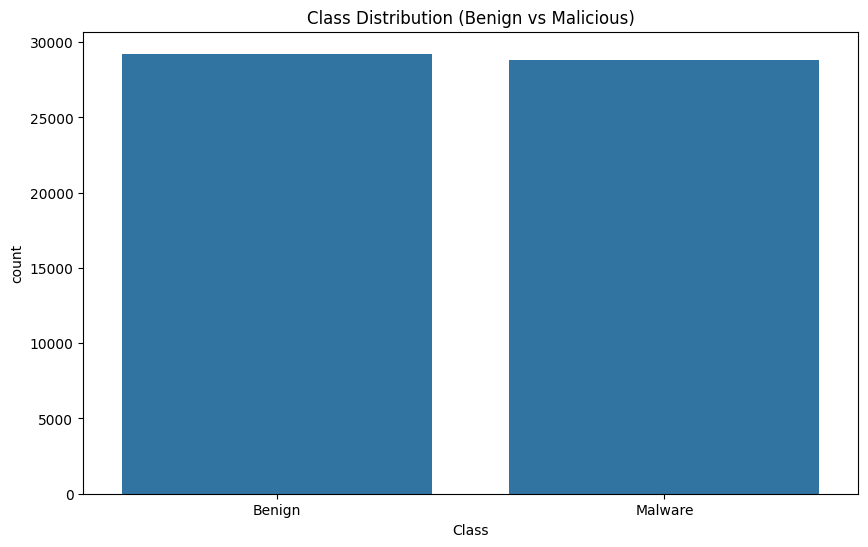

In [ ]:
# ============================================================
# STEP 2: Data Preprocessing
# ============================================================
df = pd.read_csv('Obfuscated-MalMem2022.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nClass Distribution:\n", df['Class'].value_counts())
print("\nCategory Distribution:\n", df['Category'].value_counts())

# Remove duplicates
initial_len = len(df)
df.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_len - len(df)} duplicates.")

# Check missing values
print("\nMissing Values:", df.isnull().sum().sum())

# Statistical Analysis
stats = df.describe().transpose()[['min', 'max', 'mean', 'std']]
print("\nStatistical Analysis (First 10 features):\n", stats.head(10))

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (Benign vs Malicious)')
plt.savefig('class_distribution.png')
plt.show()


In [ ]:
# ============================================================
# STEP 3: Feature Engineering & Splitting (Modified)
# ============================================================

# حذف الأعمدة التي قد تسبب Data Leakage
leakage_columns = [
    'Class',
    'Category',
    'Label',
    'Malware',
    'Family'
]

X = df.drop(columns=[col for col in leakage_columns if col in df.columns])
y = df['Class']


# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

joblib.dump(le, 'label_encoder.pkl')


# Split first
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


# Scaling after split
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


joblib.dump(scaler, 'scaler.pkl')


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (46449, 55)
Validation: (5806, 55)
Test: (5807, 55)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,657 (26.00 KB)

 Trainable params: 6,433 (25.13 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9857 - loss: 0.0504 - val_accuracy: 0.9986 - val_loss: 0.0073
Epoch 2/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9983 - loss: 0.0079 - val_accuracy: 0.9983 - val_loss: 0.0051
Epoch 3/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9986 - loss: 0.0055 - val_accuracy: 0.9995 - val_loss: 0.0013
Epoch 4/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9998 - val_loss: 7.4845e-04
Epoch 5/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9998 - val_loss: 6.5204e-04
Epoch 6/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 3.9746e-04
Epoch 7/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9990 - loss: 0.0035 - val_accuracy: 0.9991 - val_loss: 0.0030
Epoch 8/20
726/726 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9991 - loss: 0.0030 - v

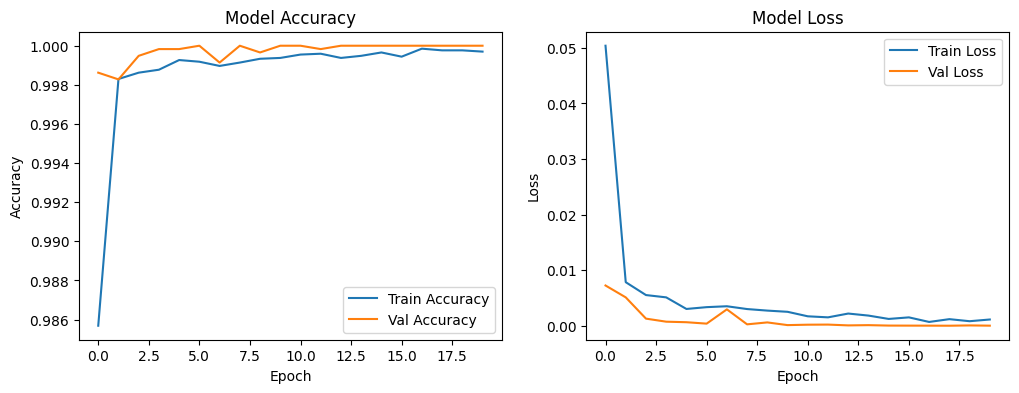

In [ ]:
# ============================================================
# STEP 4: Build & Train Model
# ============================================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

model.save('spyware_detector_model.keras')
print("\nModel saved!")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('training_history.png')
plt.show()

182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  1.0000
Recall:    1.0000
Precision: 1.0000
F1-score:  1.0000

Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      2924
     Malware       1.00      1.00      1.00      2883

    accuracy                           1.00      5807
   macro avg       1.00      1.00      1.00      5807
weighted avg       1.00      1.00      1.00      5807



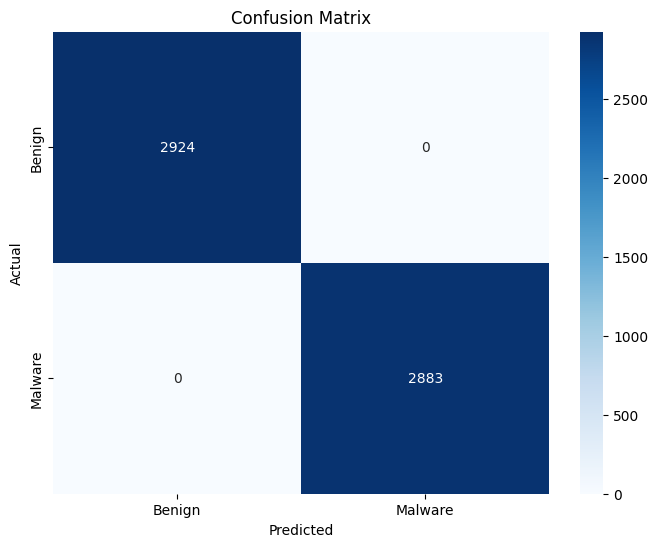

In [ ]:
# ============================================================
# STEP 5: Evaluate Model
# ============================================================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy  = accuracy_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred,
                            target_names=['Benign', 'Malware']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
# ============================================================
# STEP 6: Predict on a Sample
# ============================================================
def predict_sample(sample_data):
    sample_scaled = scaler.transform(sample_data)
    prediction_prob = model.predict(sample_scaled)
    prediction_class = (prediction_prob > 0.5).astype(int)
    class_name = le.inverse_transform(prediction_class[0])[0]
    confidence = (prediction_prob[0][0]
                  if prediction_class[0][0] == 1
                  else 1 - prediction_prob[0][0])
    return class_name, confidence

# Test with first sample
sample_raw = df.drop(columns=['Class', 'Category']).iloc[0:1]
class_name, confidence = predict_sample(sample_raw)

print(f"Sample Prediction: {class_name}")
print(f"Confidence: {confidence*100:.2f}%")
print(f"Actual Class: {'Malware' if y_test[0] == 1 else 'Benign'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Sample Prediction: Malware
Confidence: 99.93%
Actual Class: Benign
